In [ ]:
import numpy as np
import matplotlib.pylab as plt
import uproot
import awkward as ak
import seaborn
import RA_funcs as rf
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.special import gamma
from scipy.stats import skew
import Scope_funcs as sf
import pyarrow as pa

imports work
imports work


In [22]:
# plots the energy profile vs the x axis and fits to gaussian
def E_vs_X_scope_gaussian_fit(hit_data, chi2, y_min=-10, y_max=10, x_min=-20, x_max=20, bin_size = 0.4, return_param=False, Normalize=False, plane="false"):

    title = ("Shower Average Energy vs Scope X Position\n"
            r"Fit to: $y = c - A\cdot exp(\frac{-(x - \mu)^2}{2 \sigma^2})$")

    # filter data by chi2
    hit_data_chi2 = sf.filter_chi2_scope_data(hit_data,1/chi2, chi2)
    y_max, y_min

    # take the data from the seletced y range
    data = hit_data_chi2[ak.flatten((hit_data_chi2.tele.y < y_max) & (hit_data_chi2.tele.y > y_min))]
    data = data[ak.num(data.tele) == 1]


    # compute X and E
    X1 = -ak.to_numpy(ak.mean(data.tele.x, axis=1))
    X = bin_size * np.round(X1 / bin_size)
    
    if plane != "false":
        E_plane = data.hits[data.hits.plane == plane]
        E = ak.sum(E_plane.amp, axis=1)
        title = (f"Plane {plane + 1} Average Energy vs Scope X Position\n"
            r"Fit to: $y = c - A\cdot exp(\frac{-(x - \mu)^2}{2 \sigma^2})$")


    else:
        E = ak.sum(data.hits.amp, axis=1)



    # grouping
    amp, mean, pos = rf.ak_groupby(X, E, round="false")

    # statistics
    amp_avg = ak.mean(amp.data, axis=1)
    amp_std = ak.std(amp.data, axis=1) / np.sqrt(ak.num(amp.data, axis=1) - 1)

    # choose the range of X
    mask = (pos > x_min) & (pos < x_max)

    # convert Awkward → Numpy
    pos_m = ak.to_numpy(pos[mask])
    amp_m = ak.to_numpy(amp_avg[mask])
    err_m = ak.to_numpy(amp_std[mask])

    # Fitting

    #  Gaussian model 
    def gaussian_linear(x, c, A, mu, sigma):
        return c - A * np.exp(-(x - mu)**2 / (2 * sigma**2))

    # initial guesses
    c0 = 6000
    A0 = np.min(amp_m)
    # mu0 = pos_m[np.argmin(amp_m)]
    mu0 = 0
    sigma0 = 3
    # sigma0 = (np.max(pos_m) - np.min(pos_m)) / 6


    # fit
    popt, pcov = curve_fit(gaussian_linear, pos_m, amp_m, p0=[c0, A0, mu0, sigma0], sigma=err_m, absolute_sigma=True)

    # fitted values
    c_fit, A_fit, mu_fit, sigma_fit = popt
    
    # uncertainties
    perr = np.sqrt(np.diag(pcov))  # 1-sigma uncertainties
    c_err,  A_err, mu_err, sigma_err = perr

    # return the fitting results if needed
    if return_param:
        return popt, perr


    # chi2
    residuals = amp_m - gaussian_linear(pos_m, *popt)

    # avoid division by zero if any std are 0
    mask_err = err_m > 0
    chi2_val = np.sum((residuals[mask_err] / err_m[mask_err])**2)

    # number of points used in chi2
    N = np.sum(mask_err)
    
    # number of fit params (c, m, A, mu, sigma) = 5
    p = len(popt)
    ndof = N - p
    chi2_ndof = chi2_val / ndof if ndof > 0 else np.nan

    # plot
    fig, ax = plt.subplots()
    ax.errorbar(pos_m, amp_m, yerr=err_m, fmt='.', capsize=4, label="data")

    # make a smooth fitted function
    x_fit = np.linspace(np.min(pos_m), np.max(pos_m), 500)
    y_fit = gaussian_linear(x_fit, *popt)
    ax.plot(x_fit, y_fit, 'r-', label="Gaussian fit", zorder=10)

    # build textbox string
    textstr = "\n".join([
        r"$\chi^2/\mathrm{ndof} = %.2f$" % chi2_ndof,
        r"$c = %.3f \pm %.3f$" % (c_fit, c_err),
        r"$A = %.3f \pm %.3f$" % (A_fit, A_err),
        r"$\mu = %.3f \pm %.3f$" % (mu_fit, mu_err),
        r"$\sigma = %.3f \pm %.3f$" % (sigma_fit, sigma_err),
    ])

    # add textbox (axes coordinates: 0..1)
    ax.text(
        0.65, 0.36, textstr,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="pink", alpha=0.8, edgecolor="0.5")
    )

    ax.grid(True)
    ax.set_xlabel("X Scope")
    ax.set_ylabel("Energy [ADC] (avg ± std)")
    # ax.set_title(r"Average Energy vs Scope X Position \n Fit to $y = m \cdot x + c - A\cdot e^{\frac{-(x - \mu)^2}{(2 \sigma^2)}}$")
    ax.set_title(title)

    ax.legend(loc="upper left")
    # leg = ax.legend(loc="upper right", title=textstr, frameon=True)
    
    if Normalize:
        import matplotlib.ticker as ticker        
        # Define the division logic (e.g., divide by 1000)
        ax.set_yticks(np.linspace(0, c_fit, 11))
        formatter = ticker.FuncFormatter(lambda x, pos: f'{x/c_fit:.2f}')
        ax.yaxis.set_major_formatter(formatter)

    plt.show()



In [ ]:
# get the gap parameters for each layer
def gap_per_layer(scope_data,chi2, y_min=-10, y_max=10, x_min=-20, x_max=20, bin_size = 0.4):

        
    plt.rcParams.update({
        "axes.titlesize": 100,
        "axes.labelsize": 20,
        "xtick.labelsize": 15,
        "ytick.labelsize": 15,
        "legend.fontsize": 14
    })

    plt.rcParams["figure.titlesize"] = 20


    # get the parameters per plane
    c_list = []
    c_err_list = []
    A_list = []
    A_err_list = []
    mu_list = []
    mu_err_list = []

    for plane in range(0,8):
        
        popt, perr = E_vs_X_scope_gaussian_fit(scope_data, chi2, y_min, y_max, x_min, x_max, bin_size, plane=plane, return_param=True)

        c_fit, c_err = popt[0], perr[0]
        A_fit, A_err = popt[1], perr[1]
        mu_fit, mu_err = popt[2], perr[2]

        c_list.append(c_fit)
        c_err_list.append(c_err)
        A_list.append(A_fit)
        A_err_list.append(A_err)
        mu_list.append(mu_fit)
        mu_err_list.append(mu_err)

    planes = 1 + np.arange(len(c_list))  # 0..7

    fig, axs = plt.subplots(2, 1, sharex=True, figsize=(6, 4))

    # c
    axs[0].errorbar(planes, c_list, yerr=c_err_list, fmt='o-', capsize=3)
    axs[0].set_ylabel("c")
    axs[0].grid(True, alpha=0.3)

    # A
    axs[1].errorbar(planes, A_list, yerr=A_err_list, fmt='o-', capsize=3, color="r")
    axs[1].set_ylabel("A")
    axs[1].grid(True, alpha=0.3)
    axs[1].set_xlabel("Plane")

    fig.suptitle("Gap fit parameters per plane")
    plt.tight_layout()
    plt.show()



<span style="font-family: arial; font-size:25px; color:pink">

Create Run Data With Dead Pad Correction

In [ ]:
# run number
def create_pad_corrected_data(run_number, correction_radius=6, aligned=True):

    # call the data
    if aligned:
        data_scope = sf.get_ROOT_data_zip_Aligned(run_number)
    else:
        data_scope = sf.DUT_TELE_merge(run_number)

    # create the corrected data
    path = f"TB_FIRE/TB_reco/TB_FIRE_{run_number}_raw_reco_diagnostics.root"
    data_scope_corrected = rf.reconstruct_data_all_dead_pads(data_scope, correction_radius, path)

    # Save to a file
    ak.to_parquet(data_scope_corrected, f"TB_FIRE/Pad_Corrected_Data/run_{run_number}_pad_corrected.parquet")

    return





In [23]:
create_pad_corrected_data(1079, correction_radius=7, aligned=True)
create_pad_corrected_data(1089, correction_radius=7, aligned=True)

shower center: 211
we got the data
amount of dead channels: 139
{plane_ID: 1, channel_ID: 77}
60 channels left
{plane_ID: 1, channel_ID: 133}
59 channels left
{plane_ID: 1, channel_ID: 171}
58 channels left
{plane_ID: 2, channel_ID: 67}
57 channels left
{plane_ID: 2, channel_ID: 77}
56 channels left
{plane_ID: 2, channel_ID: 138}
55 channels left
{plane_ID: 2, channel_ID: 144}
54 channels left
{plane_ID: 2, channel_ID: 148}
53 channels left
{plane_ID: 2, channel_ID: 172}
52 channels left
{plane_ID: 2, channel_ID: 173}
51 channels left
{plane_ID: 2, channel_ID: 174}
50 channels left
{plane_ID: 2, channel_ID: 175}
49 channels left
{plane_ID: 2, channel_ID: 176}
48 channels left
{plane_ID: 2, channel_ID: 177}
47 channels left
{plane_ID: 2, channel_ID: 178}
46 channels left
{plane_ID: 2, channel_ID: 192}
45 channels left
{plane_ID: 2, channel_ID: 193}
44 channels left
{plane_ID: 2, channel_ID: 195}
43 channels left
{plane_ID: 2, channel_ID: 212}
42 channels left
{plane_ID: 2, channel_ID: 2

<span style="font-family: arial; font-size:25px; color:pink">

Read Pas Corrected Data and Plot Gap

In [5]:
# Load it back later
run_number = 1079
data_scope_corrected = ak.from_parquet(f"TB_FIRE/Pad_Corrected_Data/run_{run_number}_pad_corrected.parquet")

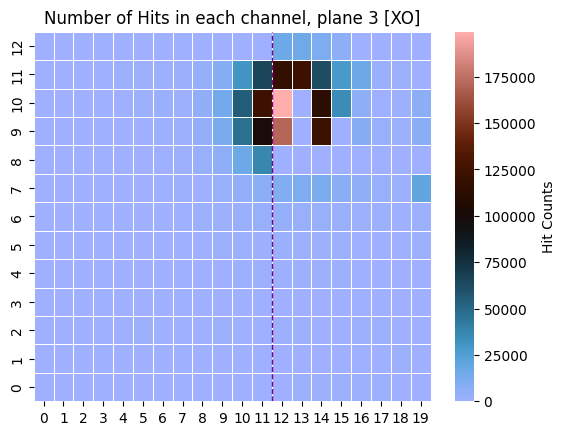

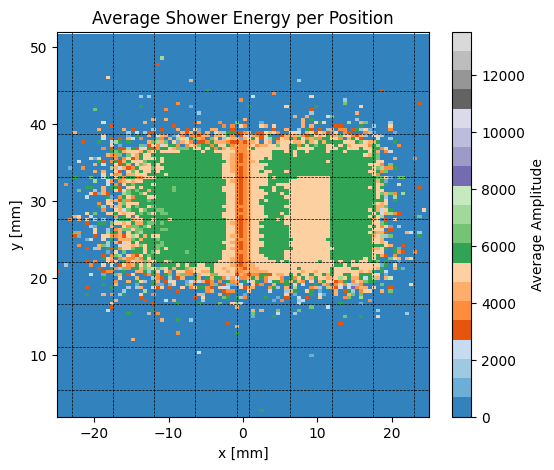

In [11]:
# hits colormap
rf.hits_amount_colormap_single_plane(data_scope_corrected.hits, 3)

# (xy) amp colormap
sf.avg_energy_scope_colormap(data_scope_corrected, x_borders=25, y_center=27, y_borders=25)


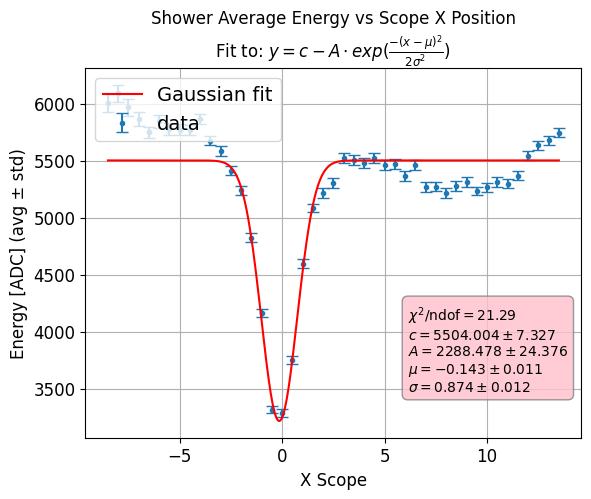

In [21]:
# E vs X
plt.rcParams.update({
        "axes.titlesize": 12,
        "axes.labelsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 14
    })

E_vs_X_scope_gaussian_fit(data_scope_corrected, 1.1, 25, 35, -9, 14, bin_size=0.5)

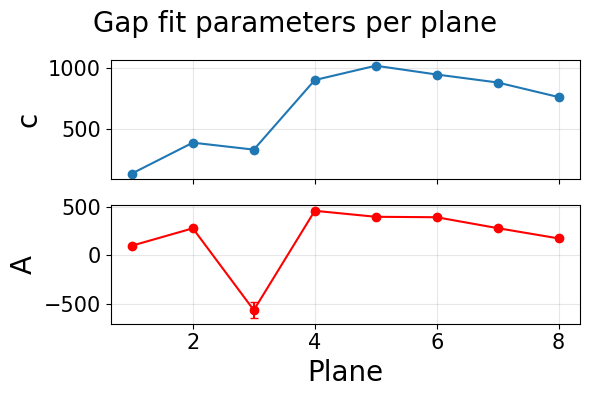

In [19]:
gap_per_layer(data_scope_corrected, 1.1, 25, 35, -9, 14, bin_size=0.5)

<span style="font-family: arial; font-size:25px; color:pink">

1079


In [14]:
data_scope_1079 = sf.get_ROOT_data_zip_Aligned(1079)

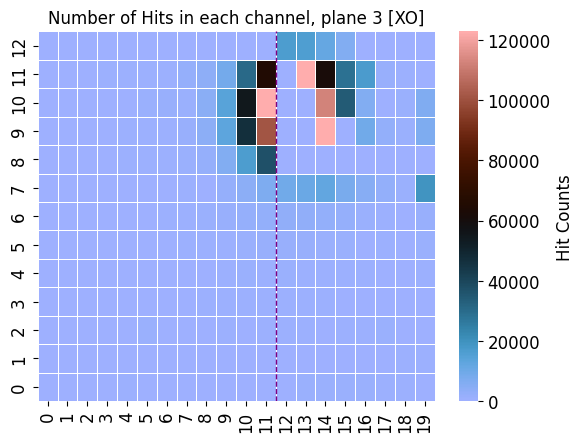

In [15]:
rf.hits_amount_colormap_single_plane(data_scope_1079.hits, 3)

In [16]:
path = "TB_FIRE/TB_reco/TB_FIRE_1079_raw_reco_diagnostics.root"
data_scope_1079_corrected = rf.reconstruct_data_all_dead_pads(data_scope_1079, 5, path)

shower center: 211
we got the data
amount of dead channels: 139
{plane_ID: 1, channel_ID: 133}
37 channels left
{plane_ID: 1, channel_ID: 171}
36 channels left
{plane_ID: 2, channel_ID: 148}
35 channels left
{plane_ID: 2, channel_ID: 172}
34 channels left
{plane_ID: 2, channel_ID: 173}
33 channels left
{plane_ID: 2, channel_ID: 174}
32 channels left
{plane_ID: 2, channel_ID: 175}
31 channels left
{plane_ID: 2, channel_ID: 176}
30 channels left
{plane_ID: 2, channel_ID: 192}
29 channels left
{plane_ID: 2, channel_ID: 193}
28 channels left
{plane_ID: 2, channel_ID: 195}
27 channels left
{plane_ID: 2, channel_ID: 212}
26 channels left
{plane_ID: 2, channel_ID: 213}
25 channels left
{plane_ID: 2, channel_ID: 232}
24 channels left
{plane_ID: 2, channel_ID: 246}
23 channels left
{plane_ID: 2, channel_ID: 247}
22 channels left
{plane_ID: 2, channel_ID: 248}
21 channels left
{plane_ID: 2, channel_ID: 249}
20 channels left
{plane_ID: 2, channel_ID: 250}
19 channels left
{plane_ID: 2, channel_ID

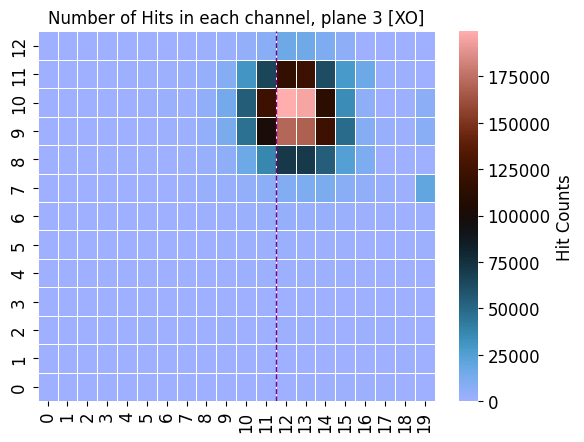

In [17]:
rf.hits_amount_colormap_single_plane(data_scope_1079_corrected.hits, 3)

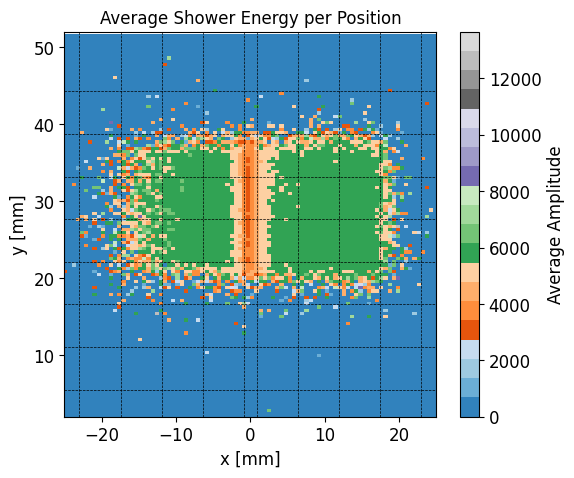

In [18]:
sf.avg_energy_scope_colormap(data_scope_1079_corrected, x_borders=25, y_center=27, y_borders=25)
# sf.avg_energy_scope_colormap(data_scope_1079, x_borders=25, y_borders=25)

/Users/bentalmor/Desktop/LUXE/F-Cal-TB-Project/venv_2026/lib/python3.14/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Gaussian fit parameters:
c     = 5718.538
A     = 2408.879
mu    = -0.143
sigma = 0.988


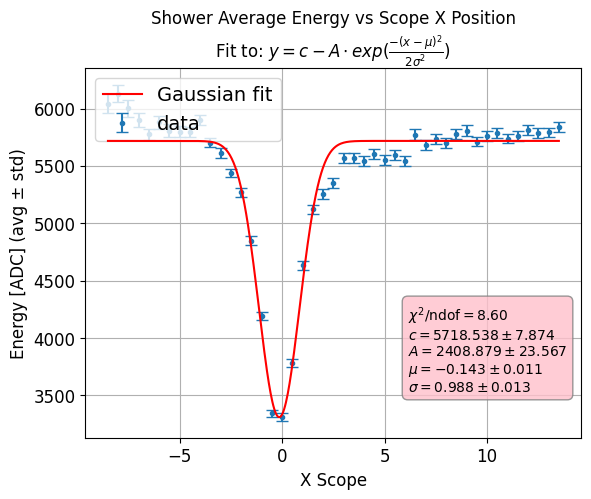

In [28]:
plt.rcParams.update({
        "axes.titlesize": 12,
        "axes.labelsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 14
    })

E_vs_X_scope_gaussian_fit(data_scope_1079_corrected, 1.1, 25, 35, -9, 14, bin_size=0.5)

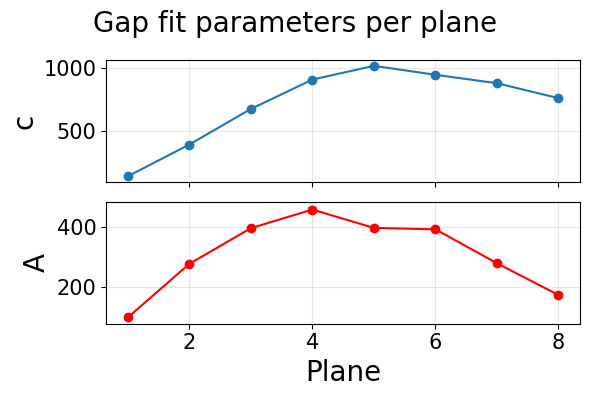

In [21]:
gap_per_layer(data_scope_1079_corrected, 1.1, 25, 35, -9, 14, bin_size=0.5)

<span style="font-family: arial; font-size:25px; color:pink">
1080


In [22]:
data_scope_1080 = sf.DUT_TELE_merge(1080)

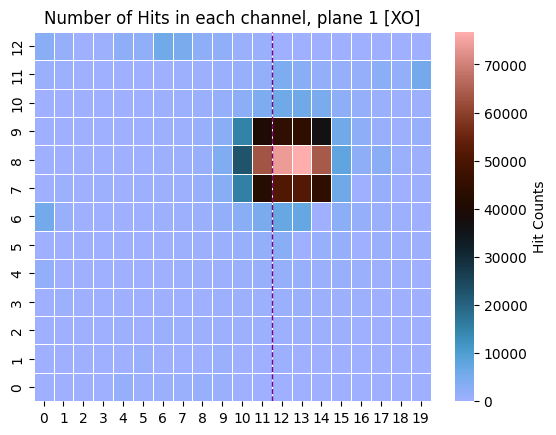

In [12]:
rf.hits_amount_colormap_single_plane(data_scope_1080.hits, 1)

In [13]:
path = "TB_FIRE/TB_reco/TB_FIRE_1080_raw_reco_diagnostics.root"
data_scope_1080_corrected = rf.reconstruct_data_all_dead_pads(data_scope_1080, 5, path)

shower center: 171
we got the data
amount of dead channels: 139
{plane_ID: 1, channel_ID: 133}
46 channels left
{plane_ID: 1, channel_ID: 255}
45 channels left
{plane_ID: 2, channel_ID: 67}
44 channels left
{plane_ID: 2, channel_ID: 148}
43 channels left
{plane_ID: 2, channel_ID: 172}
42 channels left
{plane_ID: 2, channel_ID: 173}
41 channels left
{plane_ID: 2, channel_ID: 174}
40 channels left
{plane_ID: 2, channel_ID: 175}
39 channels left
{plane_ID: 2, channel_ID: 176}
38 channels left
{plane_ID: 2, channel_ID: 192}
37 channels left
{plane_ID: 2, channel_ID: 193}
36 channels left
{plane_ID: 2, channel_ID: 195}
35 channels left
{plane_ID: 2, channel_ID: 212}
34 channels left
{plane_ID: 2, channel_ID: 213}
33 channels left
{plane_ID: 2, channel_ID: 232}
32 channels left
{plane_ID: 2, channel_ID: 246}
31 channels left
{plane_ID: 2, channel_ID: 247}
30 channels left
{plane_ID: 2, channel_ID: 248}
29 channels left
{plane_ID: 2, channel_ID: 249}
28 channels left
{plane_ID: 2, channel_ID:

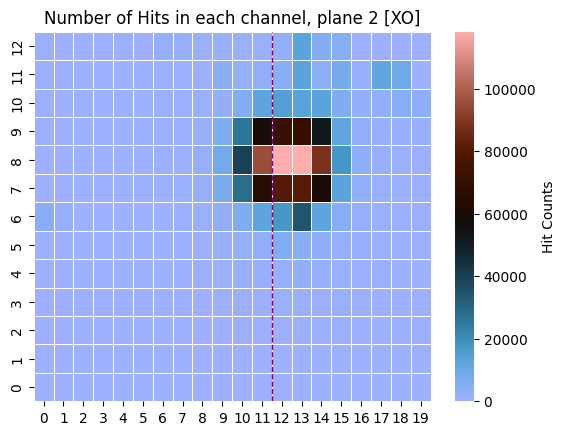

In [14]:
rf.hits_amount_colormap_single_plane(data_scope_1080_corrected.hits, 2)

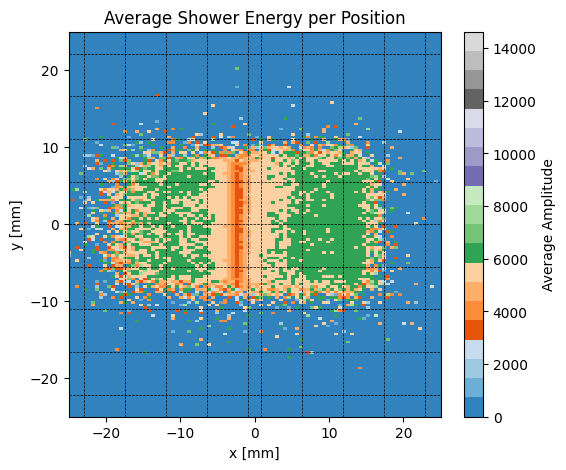

In [15]:
sf.avg_energy_scope_colormap(data_scope_1080_corrected, x_borders=25, y_borders=25)

Gaussian fit parameters:
c     = 5886.363
A     = 2468.832
mu    = -2.296
sigma = 1.017


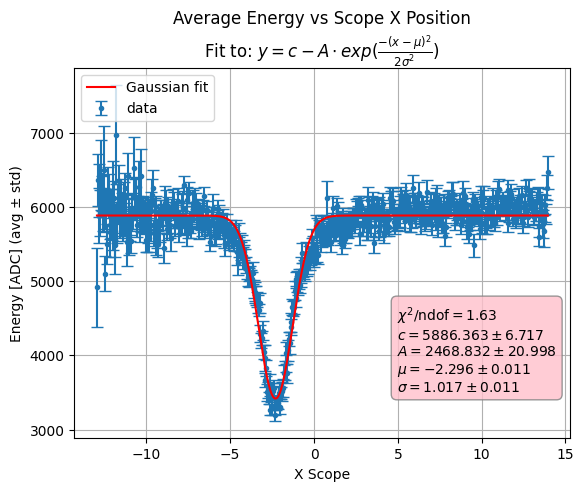

In [100]:
E_vs_X_scope_gaussian_fit(data_scope_1080_corrected, 1.1, -5, 5, -13, 14, bin_size=0.05)

In [17]:
# # histogram of the total amp from an event in a specific plane - sums the amp from all the activated pads in the event
# def amp_histo_single_plane_total_event(hit_data, plane):

#     # change index so that the first plane is 0 and the last is 7
#     plane = 8 - plane

#     # get the data of the wanted plane
#     hit_plane = hit_data[hit_data.plane == plane]

#     # create an array of only the amplitudes in the wanted plane
#     hit_plane_amp = hit_plane.amp
#     hit_plane_amp_clean = hit_plane_amp[ak.num(hit_plane_amp) > 0]
#     sum_plane_amp = ak.sum(hit_plane_amp_clean, axis = 1)


#     # create and plot an histo to count how many time did we get each amp
#     counts, bins, patches = plt.hist(sum_plane_amp, bins=501, range=(0,500))
#     max_bin_index = np.argmax(counts)
#     peaks, _ = find_peaks(counts, prominence = 170)
#     peak_x = (bins[peaks] + bins[peaks + 1]) / 2

#     # get the most common amp
#     max_bin_center = (bins[max_bin_index] + bins[max_bin_index + 1]) / 2
#     max_inputs = np.round(max_bin_center)

#     # plot settings
#     # plt.axvline(max_inputs, color='red', linestyle='--', label= max_inputs)
#     colors = ['green', 'blue', 'orange', 'purple', 'pink']
#     for i, px in enumerate(peak_x[1:len(colors)+1]):
#         plt.axvline(px, color=colors[i], linestyle='--', linewidth=1, label= np.round(px))
#     plt.legend()
#     plt.grid(which='major', linestyle='-', linewidth=0.7)
#     plt.grid(which='minor', linestyle=':', linewidth=0.5)
#     plt.minorticks_on()
#     plt.title(f'Amplitude of Hits Counter, plane {plane+1} XO', fontsize=16)
#     plt.xlabel('Amplitude', fontsize=14)
#     plt.ylabel('Counts', fontsize=14)
#     plt.show()

# amp_histo_single_plane_total_event(data_scope_1080_corrected.hits,8)

<span style="font-family: arial; font-size:25px; color:pink">
1081

In [23]:
data_scope_1081 = sf.DUT_TELE_merge(1081)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/bentalmor/Desktop/LUXE/F-Cal-TB-Project/TB_FIRE/TB_reco/TB_FIRE_1081_raw_reco.root'

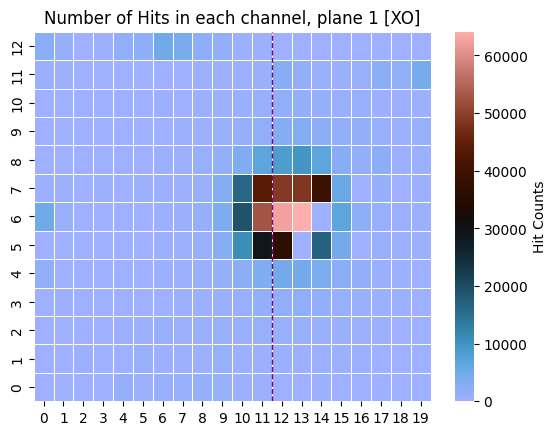

In [ ]:
rf.hits_amount_colormap_single_plane(data_scope_1081.hits, 1)

In [ ]:
path = "TB_FIRE\TB_reco\TB_FIRE_1081_raw_reco_diagnostics.root"
data_scope_1081_corrected = rf.reconstruct_data_all_dead_pads(data_scope_1081, 5, path)

<>:1: SyntaxWarning: invalid escape sequence '\T'
<>:1: SyntaxWarning: invalid escape sequence '\T'
C:\Users\bents\AppData\Local\Temp\ipykernel_708\3126317737.py:1: SyntaxWarning: invalid escape sequence '\T'
  path = "TB_FIRE\TB_reco\TB_FIRE_1081_raw_reco_diagnostics.root"


shower center: 133
we got the data
amount of dead channels: 139
{plane_ID: 1, channel_ID: 77}
45 channels left
{plane_ID: 1, channel_ID: 133}
44 channels left
{plane_ID: 2, channel_ID: 32}
43 channels left
{plane_ID: 2, channel_ID: 50}
42 channels left
{plane_ID: 2, channel_ID: 54}
41 channels left
{plane_ID: 2, channel_ID: 77}
40 channels left
{plane_ID: 2, channel_ID: 138}
39 channels left
{plane_ID: 2, channel_ID: 148}
38 channels left
{plane_ID: 2, channel_ID: 172}
37 channels left
{plane_ID: 2, channel_ID: 173}
36 channels left
{plane_ID: 2, channel_ID: 174}
35 channels left
{plane_ID: 2, channel_ID: 175}
34 channels left
{plane_ID: 2, channel_ID: 176}
33 channels left
{plane_ID: 2, channel_ID: 178}
32 channels left
{plane_ID: 2, channel_ID: 192}
31 channels left
{plane_ID: 2, channel_ID: 193}
30 channels left
{plane_ID: 2, channel_ID: 195}
29 channels left
{plane_ID: 2, channel_ID: 212}
28 channels left
{plane_ID: 2, channel_ID: 213}
27 channels left
{plane_ID: 2, channel_ID: 217

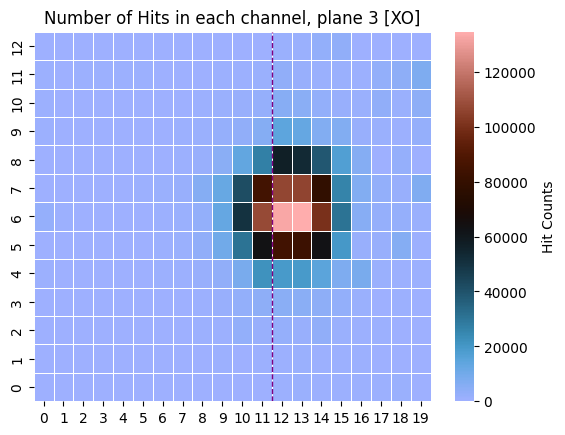

In [ ]:
rf.hits_amount_colormap_single_plane(data_scope_1081_corrected.hits, 3)

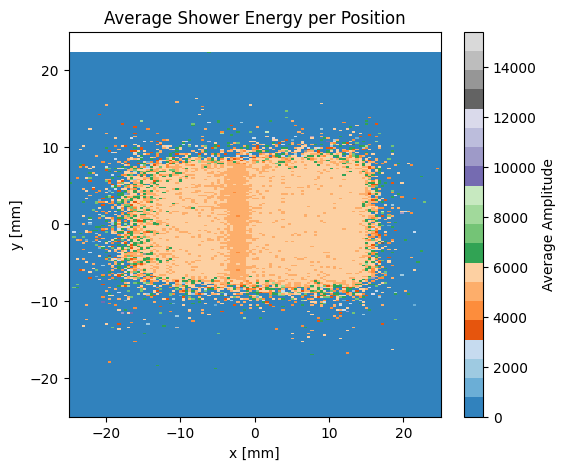

In [ ]:
sf.avg_energy_scope_colormap(data_scope_1081_corrected, x_borders=25, y_borders=25)

In [19]:
sf.E_vs_X_scope_gaussian_fit(data_scope_1081_corrected, 0.5, -10, 10, -13, 14, bin_size=0.05)

NameError: name 'data_scope_1081_corrected' is not defined

<span style="font-family: arial; font-size:25px; color:pink">
1088

In [25]:
data_scope_1088 = sf.DUT_TELE_merge(1088)

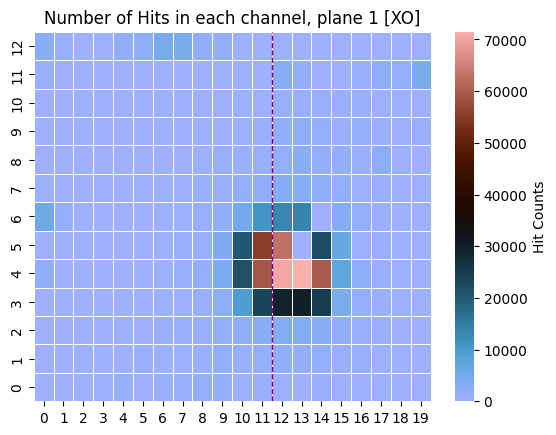

In [26]:
rf.hits_amount_colormap_single_plane(data_scope_1088.hits, 1)

In [30]:
path = "TB_FIRE/TB_reco/TB_FIRE_1088_raw_reco_diagnostics.root"
data_scope_1088_corrected = rf.reconstruct_data_all_dead_pads(data_scope_1088, 5, path)

shower center: 112
we got the data
amount of dead channels: 140
{plane_ID: 1, channel_ID: 77}
48 channels left
{plane_ID: 1, channel_ID: 133}
47 channels left
{plane_ID: 2, channel_ID: 32}
46 channels left
{plane_ID: 2, channel_ID: 50}
45 channels left
{plane_ID: 2, channel_ID: 54}
44 channels left
{plane_ID: 2, channel_ID: 67}
43 channels left
{plane_ID: 2, channel_ID: 77}
42 channels left
{plane_ID: 2, channel_ID: 148}
41 channels left
{plane_ID: 2, channel_ID: 172}
40 channels left
{plane_ID: 2, channel_ID: 173}
39 channels left
{plane_ID: 2, channel_ID: 174}
38 channels left
{plane_ID: 2, channel_ID: 175}
37 channels left
{plane_ID: 2, channel_ID: 176}
36 channels left
{plane_ID: 2, channel_ID: 177}
35 channels left
{plane_ID: 2, channel_ID: 192}
34 channels left
{plane_ID: 2, channel_ID: 193}
33 channels left
{plane_ID: 2, channel_ID: 195}
32 channels left
{plane_ID: 2, channel_ID: 212}
31 channels left
{plane_ID: 2, channel_ID: 213}
30 channels left
{plane_ID: 2, channel_ID: 217}

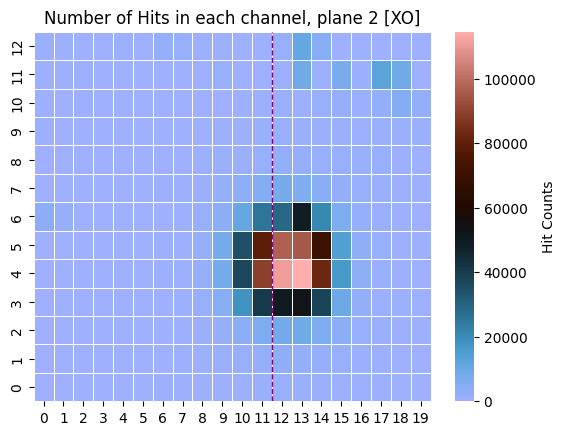

In [33]:
rf.hits_amount_colormap_single_plane(data_scope_1088_corrected.hits, 2)

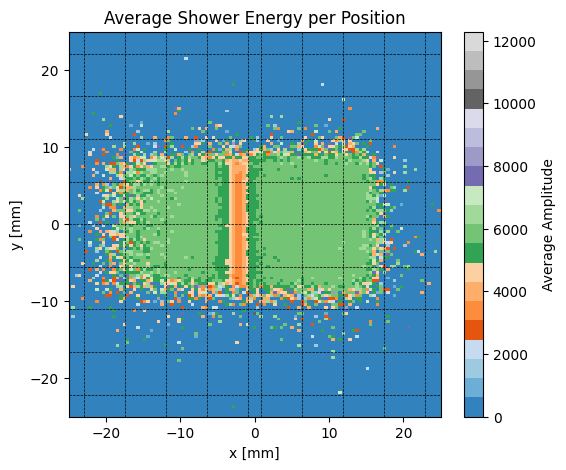

In [34]:
sf.avg_energy_scope_colormap(data_scope_1088_corrected, x_borders=25, y_borders=25)

Gaussian fit parameters:
c     = 5821.056
A     = 2403.244
mu    = -2.231
sigma = 1.017


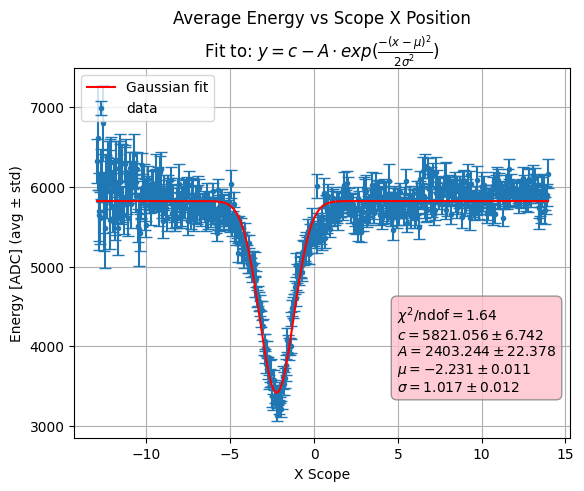

In [102]:
# E_vs_X_scope_gaussian_fit(data_scope_1088_corrected, 0.5, -10, 10, -13, 14, bin_size=0.05)
E_vs_X_scope_gaussian_fit(data_scope_1088_corrected, 1.1, -5, 5, -13, 14, bin_size=0.05)

<span style="font-family: arial; font-size:25px; color:pink">
1089

In [41]:
data_scope_1089 = sf.DUT_TELE_merge(1089)


In [42]:
data_scope_1089

<Array [{hits: [...], tele: [{...}]}, ...] type='452025 * {hits: var * {pla...'>

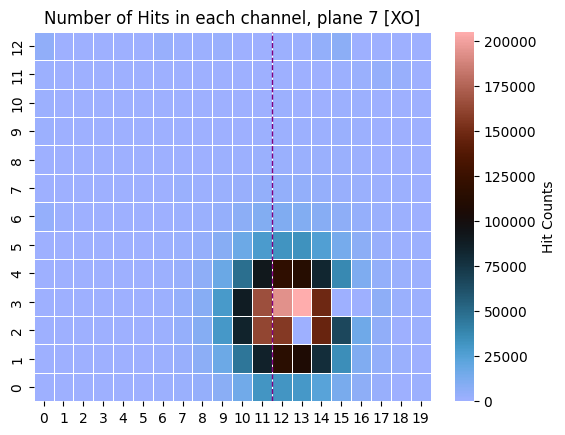

In [43]:
rf.hits_amount_colormap_single_plane(data_scope_1089.hits, 7)

In [44]:
path = "TB_FIRE/TB_reco/TB_FIRE_1089_raw_reco_diagnostics.root"
data_scope_1089_corrected = rf.reconstruct_data_all_dead_pads(data_scope_1089, 5, path)

shower center: 71
we got the data
amount of dead channels: 141
{plane_ID: 1, channel_ID: 133}
40 channels left
{plane_ID: 2, channel_ID: 7}
39 channels left
{plane_ID: 2, channel_ID: 32}
38 channels left
{plane_ID: 2, channel_ID: 50}
37 channels left
{plane_ID: 2, channel_ID: 54}
36 channels left
{plane_ID: 2, channel_ID: 67}
35 channels left
{plane_ID: 2, channel_ID: 148}
34 channels left
{plane_ID: 2, channel_ID: 172}
33 channels left
{plane_ID: 2, channel_ID: 173}
32 channels left
{plane_ID: 2, channel_ID: 174}
31 channels left
{plane_ID: 2, channel_ID: 175}
30 channels left
{plane_ID: 2, channel_ID: 176}
29 channels left
{plane_ID: 3, channel_ID: 12}
28 channels left
{plane_ID: 3, channel_ID: 13}
27 channels left
{plane_ID: 3, channel_ID: 32}
26 channels left
{plane_ID: 3, channel_ID: 36}
25 channels left
{plane_ID: 3, channel_ID: 135}
24 channels left
{plane_ID: 4, channel_ID: 7}
23 channels left
{plane_ID: 4, channel_ID: 10}
22 channels left
{plane_ID: 4, channel_ID: 11}
21 chann

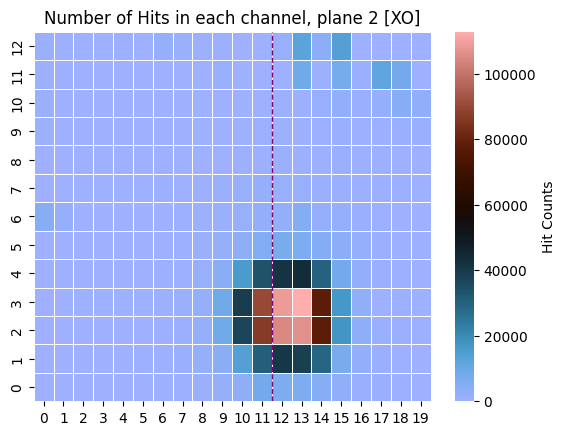

In [45]:
rf.hits_amount_colormap_single_plane(data_scope_1089_corrected.hits, 2)

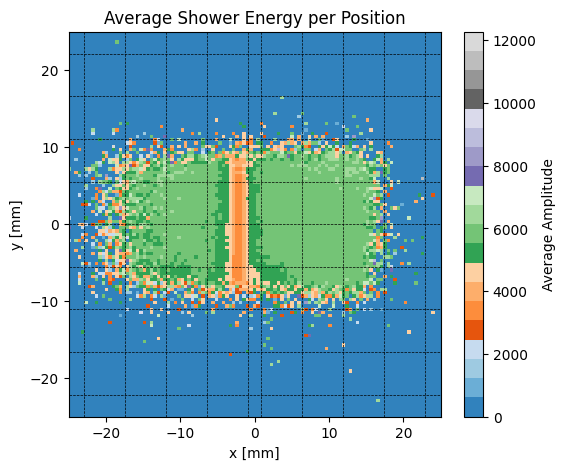

In [46]:
sf.avg_energy_scope_colormap(data_scope_1089_corrected, x_borders=25, y_borders=25)

Gaussian fit parameters:
c     = 5818.496
A     = 2458.873
mu    = -2.208
sigma = 1.071


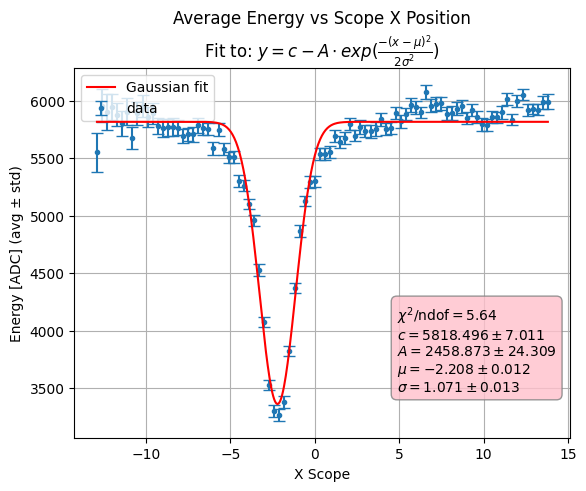

In [142]:
ymin = -5
E_vs_X_scope_gaussian_fit(data_scope_1089_corrected, 1.1, ymin, ymin+10, -13, 14, bin_size=0.3)

<span style="font-family: arial; font-size:25px; color:pink">
1089 Aligned

In [59]:
data_scope_1089_aligned = sf.get_ROOT_data_zip_Aligned(1089)

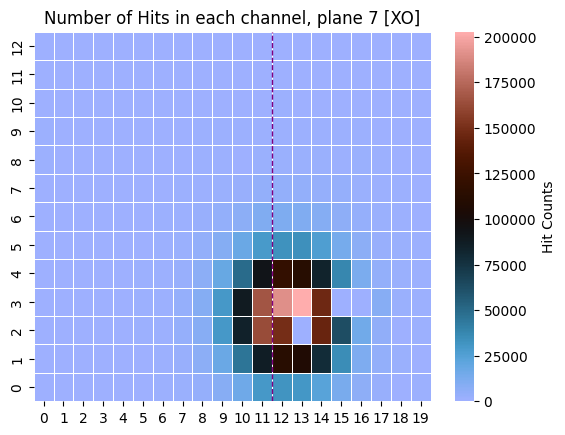

In [60]:
rf.hits_amount_colormap_single_plane(data_scope_1089_aligned.hits, 7)

In [61]:
path = "TB_FIRE/TB_reco/TB_FIRE_1089_raw_reco_diagnostics.root"
data_scope_1089_corrected_aligned = rf.reconstruct_data_all_dead_pads(data_scope_1089_aligned, 5, path)

shower center: 71
we got the data
amount of dead channels: 141
{plane_ID: 1, channel_ID: 133}
40 channels left
{plane_ID: 2, channel_ID: 7}
39 channels left
{plane_ID: 2, channel_ID: 32}
38 channels left
{plane_ID: 2, channel_ID: 50}
37 channels left
{plane_ID: 2, channel_ID: 54}
36 channels left
{plane_ID: 2, channel_ID: 67}
35 channels left
{plane_ID: 2, channel_ID: 148}
34 channels left
{plane_ID: 2, channel_ID: 172}
33 channels left
{plane_ID: 2, channel_ID: 173}
32 channels left
{plane_ID: 2, channel_ID: 174}
31 channels left
{plane_ID: 2, channel_ID: 175}
30 channels left
{plane_ID: 2, channel_ID: 176}
29 channels left
{plane_ID: 3, channel_ID: 12}
28 channels left
{plane_ID: 3, channel_ID: 13}
27 channels left
{plane_ID: 3, channel_ID: 32}
26 channels left
{plane_ID: 3, channel_ID: 36}
25 channels left
{plane_ID: 3, channel_ID: 135}
24 channels left
{plane_ID: 4, channel_ID: 7}
23 channels left
{plane_ID: 4, channel_ID: 10}
22 channels left
{plane_ID: 4, channel_ID: 11}
21 chann

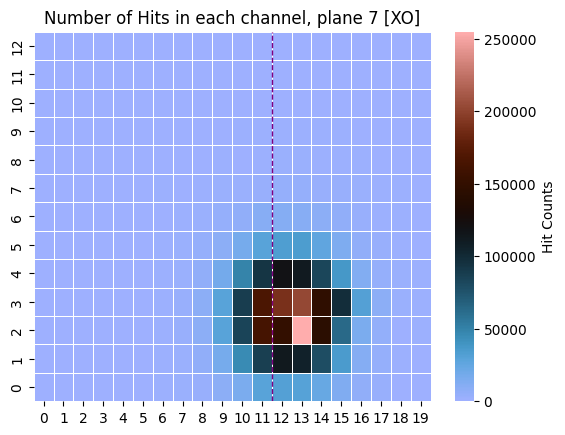

In [62]:
rf.hits_amount_colormap_single_plane(data_scope_1089_corrected_aligned.hits, 7)

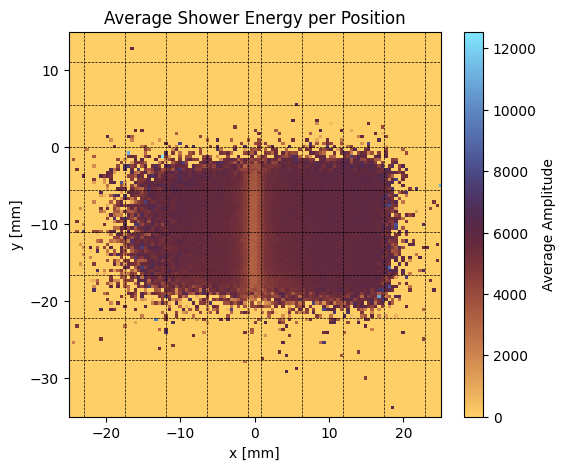

In [77]:
sf.avg_energy_scope_colormap(data_scope_1089_corrected_aligned, x_borders=25, y_center=-10, y_borders=25, cmap='managua')
# sf.avg_energy_scope_colormap(data, x_borders=25, y_borders=25)

Gaussian fit parameters:
c     = 5702.495
A     = 2469.474
mu    = -0.142
sigma = 1.014


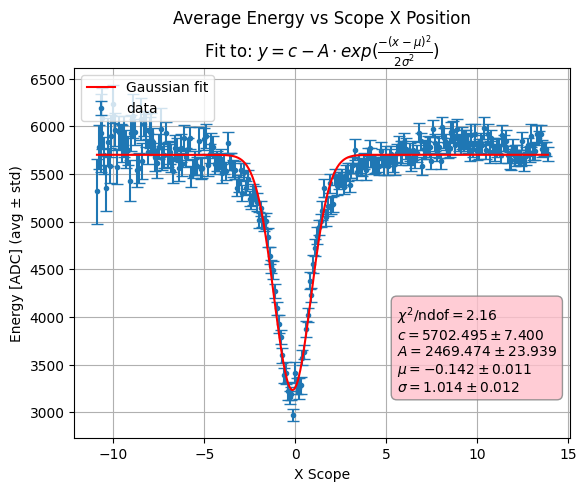

In [145]:
ymin = -15
E_vs_X_scope_gaussian_fit(data_scope_1089_corrected_aligned, 1.1, ymin, ymin+10, -11, 14, bin_size=0.1)

/Users/bentalmor/Desktop/LUXE/F-Cal-TB-Project/venv_2026/lib/python3.14/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Gaussian fit parameters:
c     = 992.259
A     = 421.295
mu    = -0.323
sigma = 1.080


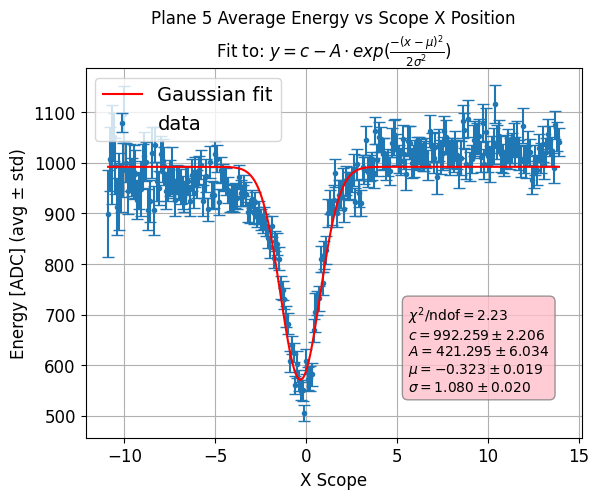

In [271]:
plt.rcParams.update({
        "axes.titlesize": 12,
        "axes.labelsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 14
    })

E_vs_X_scope_gaussian_fit(data_scope_1089_corrected_aligned, 1.1, -15, -5, -11, 14, bin_size=0.1, plane=4)

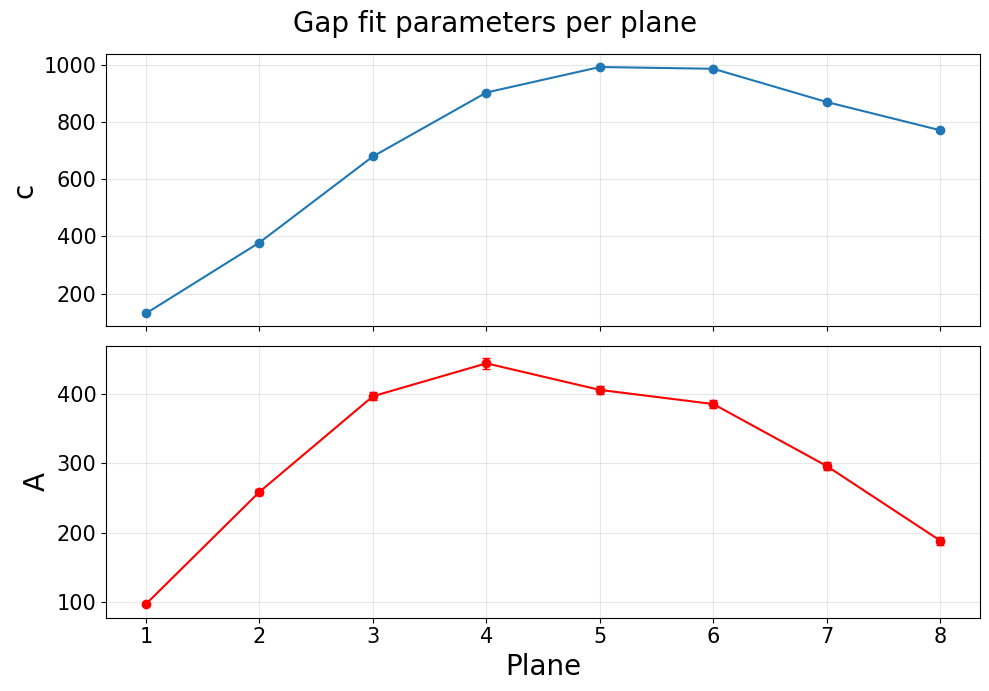

In [269]:
gap_per_layer(data_scope_1089_corrected_aligned, 1.1, -15, -5, -11, 14, bin_size=0.5)